<a href="https://colab.research.google.com/github/stephanieabisaab/lab3-text-visualisation/blob/main/lab3_part2_abi_saab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SETUP INSTALL IMPORTS
!pip install gensim sentence-transformers transformers torch datasets seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec
import gensim.downloader as api

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import seaborn as sns

print("SETUP OK")

SETUP OK


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# LOAD DATASET
dataset = load_dataset("SetFit/20_newsgroups")
df = pd.DataFrame(dataset["train"])

# CATEGORIES
my_categories = ["sci.space", "rec.sport.hockey", "talk.politics.guns"]

df = df[df["label_text"].isin(my_categories)].reset_index(drop=True)

print(df["label_text"].value_counts())


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

label_text
rec.sport.hockey      600
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


In [ ]:

# PREPROCESSING
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = text.split()  # SAFE (no nltk crash)

    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return tokens

df["tokens"] = df["text"].apply(preprocess)
df["clean"] = df["tokens"].apply(lambda x: " ".join(x))

print("PREPROCESS DONE")


PREPROCESS DONE


In [ ]:

# WORD2VEC TRAINING

corpus = df["tokens"].tolist()

cbow = Word2Vec(corpus, vector_size=100, window=5, min_count=5, sg=0, epochs=10)
skip = Word2Vec(corpus, vector_size=100, window=5, min_count=5, sg=1, epochs=10)

print("WORD2VEC DONE")


WORD2VEC DONE


In [ ]:

# TEST WORDS

test_words = ["space", "nasa", "game", "team", "gun"]

for w in test_words:
    print("\nWORD:", w)

    if w in cbow.wv:
        print("CBOW:", [x[0] for x in cbow.wv.most_similar(w, topn=5)])
        print("SKIP:", [x[0] for x in skip.wv.most_similar(w, topn=5)])
    else:
        print("NOT IN VOCAB")


WORD: space
CBOW: ['station', 'nasa', 'program', 'shuttle', 'technology']
SKIP: ['development', 'aerospace', 'technology', 'exploration', 'larc']

WORD: nasa
CBOW: ['space', 'program', 'technology', 'shuttle', 'station']
SKIP: ['ames', 'dryden', 'shafer', 'langley', 'mary']

WORD: game
CBOW: ['played', 'playoff', 'pick', 'night', 'cup']
SKIP: ['playoff', 'regularseason', 'played', 'espns', 'cup']

WORD: team
CBOW: ['nhl', 'playoff', 'league', 'player', 'season']
SKIP: ['nhl', 'drafted', 'goaltender', 'mvp', 'helsinki']

WORD: gun
CBOW: ['criminal', 'death', 'killed', 'police', 'knife']
SKIP: ['handgun', 'legally', 'riot', 'strict', 'victim']


In [ ]:
# ANALOGIES

def analogy(model, a, b, c):
    try:
        return model.wv.most_similar(positive=[b, c], negative=[a], topn=3)
    except:
        return "not enough vocab"

print("\nANALOGY TESTS")

print("space analogy:", analogy(skip, "earth", "space", "nasa"))
print("sport analogy:", analogy(skip, "player", "game", "team"))



ANALOGY TESTS
space analogy: [('administration', 0.6069502830505371), ('redesign', 0.6022236943244934), ('office', 0.6015259027481079)]
sport analogy: [('regularseason', 0.6254696846008301), ('espn', 0.6245002150535583), ('night', 0.6223360896110535)]


In [ ]:
# GLOVE

print("\nLOADING GLOVE...")
glove = api.load("glove-wiki-gigaword-100")
print("GLOVE LOADED")

word = "space"

print("\nGLOVE vs YOUR MODEL:", word)

if word in skip.wv:
    print("YOUR MODEL:", [x[0] for x in skip.wv.most_similar(word, topn=5)])
else:
    print("YOUR MODEL: not in vocab")

if word in glove:
    print("GLOVE:", [x[0] for x in glove.most_similar(word, topn=5)])
else:
    print("GLOVE: not in vocab")


LOADING GLOVE...
[==================================================] 100.0% 128.1/128.1MB downloaded
GLOVE LOADED

GLOVE vs YOUR MODEL: space
YOUR MODEL: ['development', 'aerospace', 'technology', 'exploration', 'larc']
GLOVE: ['nasa', 'spaces', 'shuttle', 'earth', 'spacecraft']


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

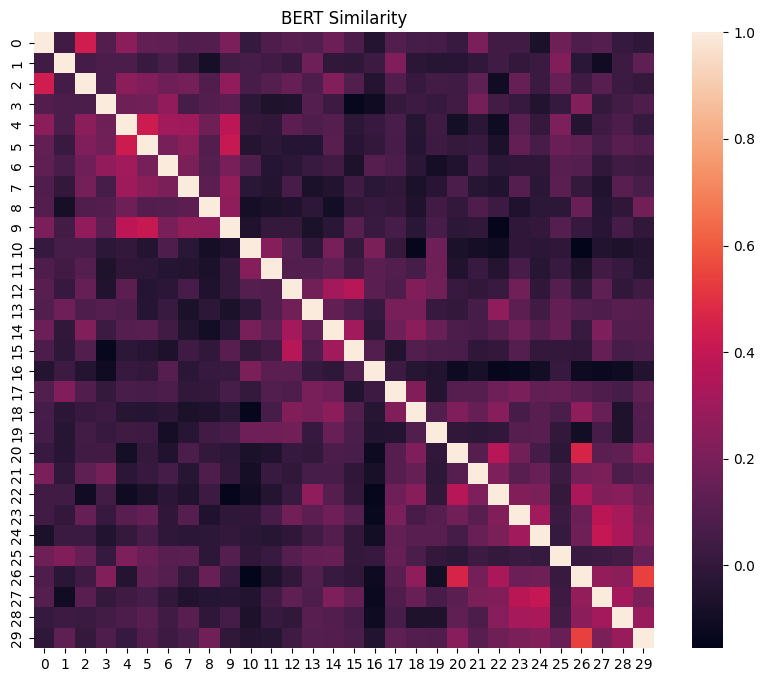

In [ ]:
# BERT SENTENCE EMBEDDING

bert = SentenceTransformer("all-MiniLM-L6-v2")

sampled = df.groupby("label_text").sample(10, random_state=42)
docs = sampled["text"].str[:500].tolist()
labels = sampled["label_text"].tolist()

emb = bert.encode(docs)
sim = cosine_similarity(emb)

plt.figure(figsize=(10,8))
sns.heatmap(sim)
plt.title("BERT Similarity")
plt.show()

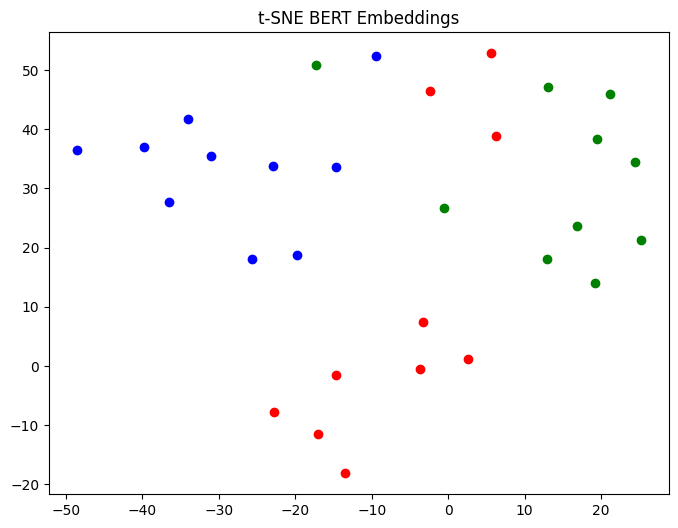

visualization ok


In [ ]:
# t-SNE VISUALIZATION
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
reduced = tsne.fit_transform(emb)

plt.figure(figsize=(8,6))

colors = {"sci.space":"red","rec.sport.hockey":"blue","talk.politics.guns":"green"}

for i, l in enumerate(labels):
    plt.scatter(reduced[i,0], reduced[i,1], color=colors[l], label=l)

plt.title("t-SNE BERT Embeddings")
plt.show()

print("visualization ok")